In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

In [2]:
def get_sp500_tickers():
  table = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")
  return table[0]['Symbol'].str.replace('.', '-', regex=False).tolist()

In [3]:
def add_moving_averages(df: pd.DataFrame, spans = [5, 10, 20, 50]):
  for span in spans:
    df[f"MA{span}"] = df["Close"].rolling(window=span).mean()
  
  return df

In [4]:
def add_rsi(df: pd.DataFrame):
  delta = df["Close"].diff()

  up = delta.clip(lower=0)
  down = -1 * delta.clip(upper=0)

  avg_gain = up.rolling(window=14).mean()
  avg_loss = down.rolling(window=14).mean()

  rs = avg_gain / avg_loss

  df["RSI14"] = 100 - (100 / (rs + 1))

  return df

In [5]:
def add_standard_deviations(df: pd.DataFrame, spans=[5, 10, 20, 50]):
  for span in spans:
    df[f"SD{span}"] = df["Close"].rolling(window=span).std()

  return df

In [6]:
def add_rate_of_change(df: pd.DataFrame, spans=[5, 10, 20, 50]):
  for span in spans:
    df[f"ROC{span}"] = df["Close"].pct_change(periods=span)

  return df

In [7]:
def add_avg_true_range(df: pd.DataFrame):
  df["HighLow"] = df["High"] - df["Low"]
  df["HighClose"] = (df["High"] - df["Close"].shift()).abs()
  df["LowClose"] = (df["Low"] - df["Close"].shift()).abs()

  df["TR"] = df[[
    "HighLow",
    "HighClose",
    "LowClose"
  ]].max(axis=1)

  df["ATR14"] = df["TR"].rolling(window=14).mean()

  df.drop(
    columns=[
      "HighLow",
      "HighClose",
      "LowClose",
      "TR"
    ],
    inplace=True
  )

  return df

In [8]:
def add_bollinger_bands(df: pd.DataFrame, window=20, no_std=2):
  rolling_mean = df["Close"].rolling(window=window).mean()
  rolling_std = df["Close"].rolling(window=window).std()

  df["BollMid"] = rolling_mean
  df["BollUpper"] = rolling_mean + (no_std * rolling_std)
  df["BollLower"] = rolling_mean - (no_std * rolling_std)

  df["BollBandwidth"] = df["BollUpper"] - df["BollLower"]

  return df

In [9]:
def add_ema(df: pd.DataFrame, spans=[5, 12, 26, 50]):
  for span in spans:
    df[f"EMA{span}"] = df["Close"].ewm(span=span).mean()

  return df

In [10]:
def add_macd(df: pd.DataFrame, short_window=12, long_window=26, signal_window=9):
  short_ema = df["Close"].ewm(span=short_window, adjust=False).mean()
  long_ema = df["Close"].ewm(span=long_window, adjust=False).mean()

  df["MACD"] = short_ema - long_ema
  df["MACD_Signal"] = df["MACD"].ewm(span=signal_window, adjust=False).mean()
  df["MACD_Histo"] = df["MACD"] - df["MACD_Signal"]

  return df

In [11]:
def add_donchian_channels(df: pd.DataFrame, window=20):
    df["DC_Lower"] = df["Low"].rolling(window=window).min()
    df["DC_Upper"] = df["High"].rolling(window=window).max()
    df["DC_Mid"] = (df["High"] + df["Low"]) / 2
    df["DC_Width"] = df["DC_Upper"] - df["DC_Lower"]
    
    df["DC_Breakout_Strength"] = (df["Close"] - df["DC_Mid"]) / df["DC_Width"]
    
    return df

In [12]:
def add_volume_features(df: pd.DataFrame):
  df["Vol_MA10"] = df["Volume"].rolling(window=10).mean()
  df["Vol_MA20"] = df["Volume"].rolling(window=20).mean()
  
  df["Vol_MA10_Ratio"] = df["Volume"] / df["Vol_MA10"]
  df["Vol_MA20_Ratio"] = df["Volume"] / df["Vol_MA20"]
  
  df["Vol_Spike"] = (df["Vol_MA10_Ratio"] > 1.5).astype(int)
  
  vol_mean = df["Volume"].rolling(window=20).mean()
  vol_std = df["Volume"].rolling(window=20).std()
  
  df["Vol_Z"] = (df["Volume"] - vol_mean) / vol_std
  
  return df

In [13]:
def add_mfi(df: pd.DataFrame, period=14):
  typical_price = (df["High"] + df["Low"] + df["Close"]) / 3

  raw_money_flow = typical_price * df["Volume"]

  delta_tp = typical_price.diff()

  pos_flow = raw_money_flow.where(delta_tp > 0, 0.0)
  neg_flow = raw_money_flow.where(delta_tp < 0, 0.0)

  pos_sum = pos_flow.rolling(window=period).sum()
  neg_sum = neg_flow.rolling(window=period).sum()

  money_flow_ratio = pos_sum / (neg_sum + 1e-9) # avoid div by zero

  money_flow_index = 100 - (100 / (1 + money_flow_ratio))

  df["MFI"] = money_flow_index

  return df

In [14]:
def add_z_close(df: pd.DataFrame):
  z_mean = df["Close"].rolling(window=20).mean()
  z_std = df["Close"].rolling(window=20).std()

  df["ZClose20"] = (df["Close"] - z_mean) / z_std

  return df

In [15]:
def add_stochastic_oscillator(df: pd.DataFrame, k_period=14, d_period=3):
  high_max = df["High"].rolling(window=k_period).max()
  low_min = df["Low"].rolling(window=k_period).min()

  df["Stoch_K%"] = 100 * (
    (df["Close"] - low_min)
    /
    (high_max - low_min + 1e-9)
  ) # avoid div by zero
  
  df["Stoch_D%"] = df["Stoch_K%"].rolling(window=d_period).mean()

  return df

In [16]:
def add_target(df: pd.DataFrame):
  df["Target"] = (df["Close"].shift(-5) / df["Close"] - 1 > 0.02).astype(int)

  return df

In [17]:
FEATURES = [
  add_target,
  add_moving_averages,
  add_rsi,
  add_standard_deviations,
  add_rate_of_change,
  add_avg_true_range,
  add_bollinger_bands,
  add_macd,
  add_ema,
  add_donchian_channels,
  add_volume_features,
  add_mfi,
  add_z_close,
  add_stochastic_oscillator
]

In [18]:
def derive_features(df: pd.DataFrame) -> pd.DataFrame:
  for f in FEATURES:
    df = f(df)

  return df

In [19]:
def process_ticker(ticker, interval="1d", period="20y"):
  try:
    df = yf.download(
      ticker,
      interval=interval,
      period=period,
      auto_adjust=True,
      progress=False
    )

    if df.empty or len(df) < 50:
      return None
    
    if isinstance(df.columns, pd.MultiIndex):
      df.columns = df.columns.get_level_values(0)

    df = derive_features(df=df)

    df.dropna(inplace=True)

    df.columns = pd.MultiIndex.from_product([df.columns, [ticker]])
    df.columns.names = ["Feature", "Ticker"]

    return df

  except Exception as e:
    print(f"Error for ticker ${ticker}: {e}")
    return None

In [20]:
def build_dataset():
  tickers = get_sp500_tickers()
  all_dfs = []

  for ticker in tqdm(tickers, desc="Processing S&P500 Tickers"):
    df = process_ticker(ticker)

    if df is not None:
      all_dfs.append(df)

  if not all_dfs:
    raise Exception("No data collected!")
  
  full_df = pd.concat(all_dfs, axis=1)

  return full_df

In [21]:
def save_parquet():
  build_dataset().to_parquet("sp500_1d_tech_indicators.parquet", engine="pyarrow", index=True)
  print("✅ Saved dataset to parquet.")

save_parquet()

Processing S&P500 Tickers: 100%|██████████| 503/503 [02:05<00:00,  4.01it/s]


✅ Saved dataset to parquet.


In [22]:
def plot_technical_indicators(ticker, interval="1d", period="6mo"):
  df = process_ticker(ticker, interval, period)

  df.columns = df.columns.droplevel(1)

  fig, axs = plt.subplots(6, 1, figsize=(14, 24), gridspec_kw={'height_ratios': [3, 1, 1, 1, 1, 1]})
  fig.suptitle(f'Technical Indicators for {ticker} - {period}', fontsize=16)
  
  # Price with Bollinger Bands
  axs[0].plot(df.index, df['Close'], label='Close Price', color='blue')
  axs[0].plot(df.index, df['BollUpper'], label='Upper Band', color='red', linestyle='--')
  axs[0].plot(df.index, df['BollMid'], label='Middle Band', color='green', linestyle='-')
  axs[0].plot(df.index, df['BollLower'], label='Lower Band', color='red', linestyle='--')
  axs[0].fill_between(df.index, df['BollUpper'], df['BollLower'], alpha=0.1, color='gray')
  axs[0].set_title('Price with Bollinger Bands')
  axs[0].legend(loc='upper left')
  axs[0].grid(True)
  
  # MACD
  axs[1].plot(df.index, df['MACD'], label='MACD', color='blue')
  axs[1].plot(df.index, df['MACD_Signal'], label='Signal Line', color='red')
  axs[1].bar(df.index, df['MACD_Histo'], label='Histogram', color='green', alpha=0.5)
  axs[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
  axs[1].set_title('MACD')
  axs[1].legend(loc='upper left')
  axs[1].grid(True)
  
  # Donchian Channels
  axs[2].plot(df.index, df['Close'], label='Close Price', color='blue')
  axs[2].plot(df.index, df['DC_Upper'], label='Upper Channel', color='green')
  axs[2].plot(df.index, df['DC_Lower'], label='Lower Channel', color='red')
  axs[2].fill_between(df.index, df['DC_Upper'], df['DC_Lower'], alpha=0.1, color='gray')
  axs[2].set_title('Donchian Channels')
  axs[2].legend(loc='upper left')
  axs[2].grid(True)
  
  # Stochastic Oscillator
  axs[3].plot(df.index, df['Stoch_K%'], label='%K', color='blue')
  axs[3].plot(df.index, df['Stoch_D%'], label='%D', color='red')
  axs[3].axhline(y=80, color='black', linestyle='--', alpha=0.3)
  axs[3].axhline(y=20, color='black', linestyle='--', alpha=0.3)
  axs[3].set_ylim(0, 100)
  axs[3].set_title('Stochastic Oscillator')
  axs[3].legend(loc='upper left')
  axs[3].grid(True)
  
  # RSI
  axs[4].plot(df.index, df['RSI14'], label='RSI', color='purple')
  axs[4].axhline(y=70, color='red', linestyle='--', alpha=0.3)
  axs[4].axhline(y=30, color='green', linestyle='--', alpha=0.3)
  axs[4].set_ylim(0, 100)
  axs[4].set_title('RSI')
  axs[4].legend(loc='upper left')
  axs[4].grid(True)
  
  # MFI
  axs[5].plot(df.index, df['MFI'], label='MFI', color='orange')
  axs[5].axhline(y=75, color='red', linestyle='--', alpha=0.3)
  axs[5].axhline(y=25, color='green', linestyle='--', alpha=0.3)
  axs[5].set_ylim(0, 100)
  axs[5].set_title('Money Flow Index (MFI)')
  axs[5].legend(loc='upper left')
  axs[5].grid(True)
  
  plt.tight_layout()
  plt.subplots_adjust(top=0.95)
  plt.show()

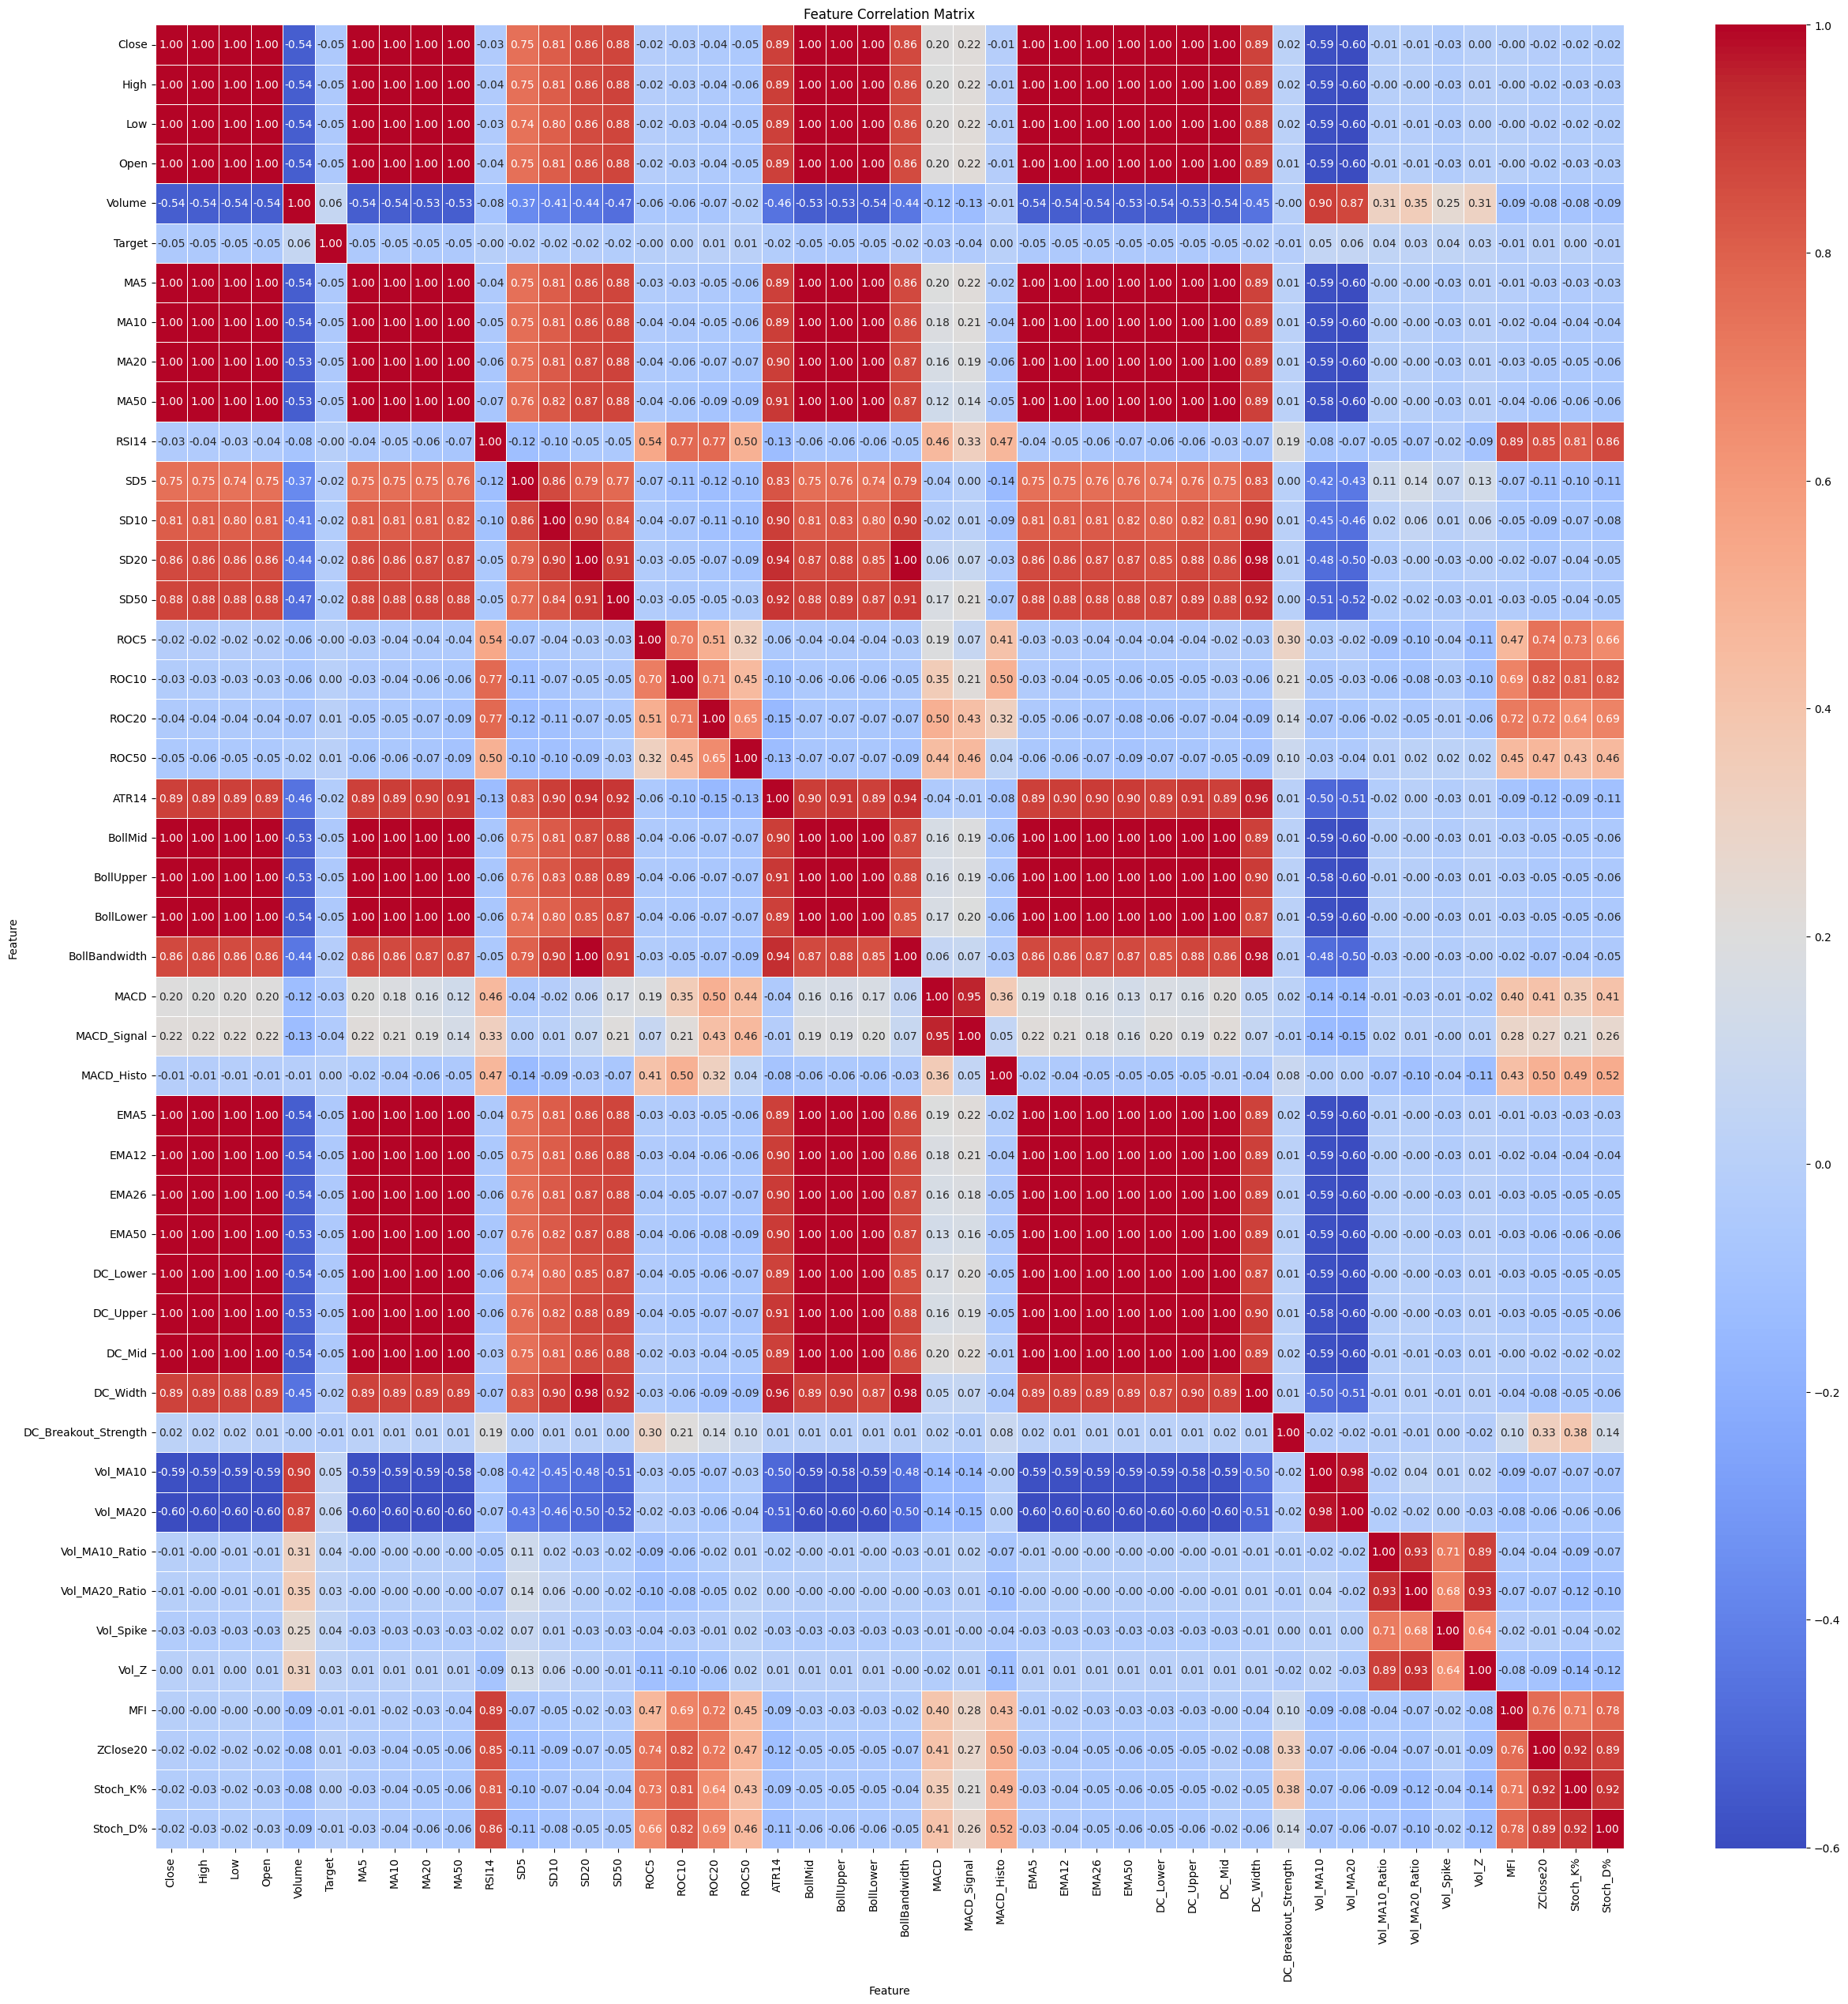

In [23]:
def plot_correlation_matrix(ticker):
  df = process_ticker(ticker)

  df.columns = df.columns.droplevel(1)

  corr_matrix = df.corr()

  plt.figure(figsize=(30, 30))
  sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, linewidths=0.5)
  plt.title("Feature Correlation Matrix")
  plt.show()

plot_correlation_matrix("AAPL")